# Random Forest Assignment — Glass Classification

## Objective
The objective of this assignment is to apply the **Random Forest classifier** on the Glass dataset and compare it with Bagging and Boosting methods.

This notebook includes:

1. Dataset loading  
2. Exploratory Data Analysis (EDA)  
3. Data visualization  
4. Missing value, duplicate, and outlier check  
5. Data preprocessing  
6. Feature scaling  
7. Imbalance handling using class weights  
8. Random Forest model implementation  
9. Model evaluation  
10. Bagging classifier  
11. Boosting classifier  
12. Model comparison  
13. Explanation of Bagging and Boosting  
14. Explanation of imbalance handling  
15. Final conclusion

## 2. Import Required Libraries

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Load Dataset

The Excel file has two sheets:
- `Description`
- `glass`

The actual dataset is present in the `glass` sheet.

In [2]:
df = pd.read_excel("glass.xlsx", sheet_name="glass")

print("Dataset Shape:", df.shape)
display(df.head())

Dataset Shape: (214, 10)


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## 4. Dataset Information

The target column is:

- `Type`

The input features are:

- `RI`
- `Na`
- `Mg`
- `Al`
- `Si`
- `K`
- `Ca`
- `Ba`
- `Fe`

In [3]:
print("Dataset Information:")
df.info()

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB

Column Names:
['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']


## 5. Missing Values and Duplicate Check

In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

# Remove duplicate rows if present
df = df.drop_duplicates()

print("\nShape after removing duplicates:", df.shape)

Missing Values:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Duplicate Rows: 1

Shape after removing duplicates: (213, 10)


## 6. Summary Statistics

In [5]:
display(df.describe())

print("Target Class Distribution:")
print(df["Type"].value_counts().sort_index())

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000
mean,1.518348,13.404085,2.679202,1.449484,72.655070,0.498873,8.954085,0.175869,0.057277,2.788732
std,0.003033,0.816662,1.443691,0.495925,0.773998,0.653185,1.425882,0.498245,0.097589,2.105130
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516520,12.900000,2.090000,1.190000,72.280000,0.130000,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.560000,8.600000,0.000000,0.000000,2.000000
75%,1.519150,13.810000,3.600000,1.630000,73.090000,0.610000,9.150000,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


Target Class Distribution:
Type
1    69
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


## 7. Exploratory Data Analysis

### 7.1 Target Class Distribution

This helps us understand whether the dataset is balanced or imbalanced.

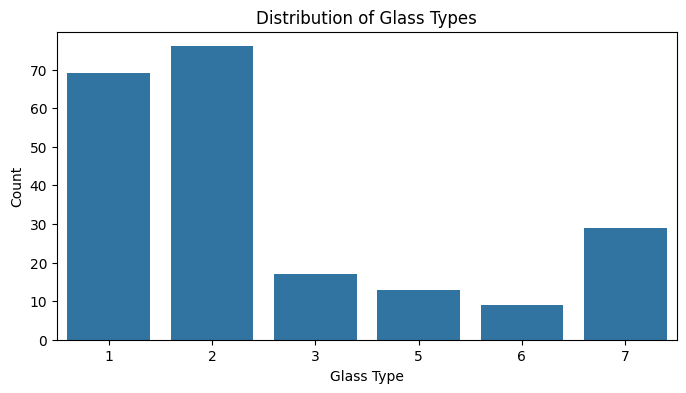

Type
1    69
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64

In [6]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x="Type", order=sorted(df["Type"].unique()))
plt.title("Distribution of Glass Types")
plt.xlabel("Glass Type")
plt.ylabel("Count")
plt.show()

class_distribution = df["Type"].value_counts().sort_index()
display(class_distribution)

## 7.2 Feature Distributions using Histograms

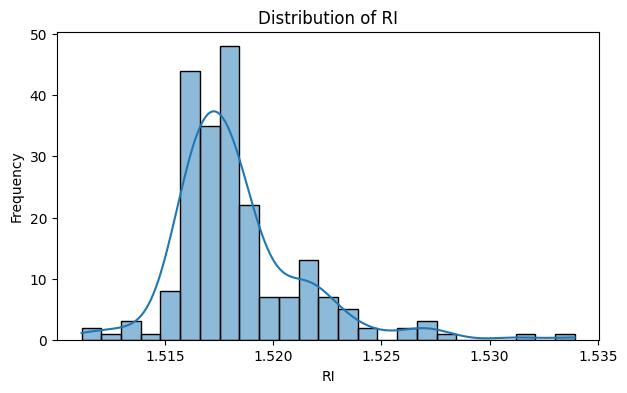

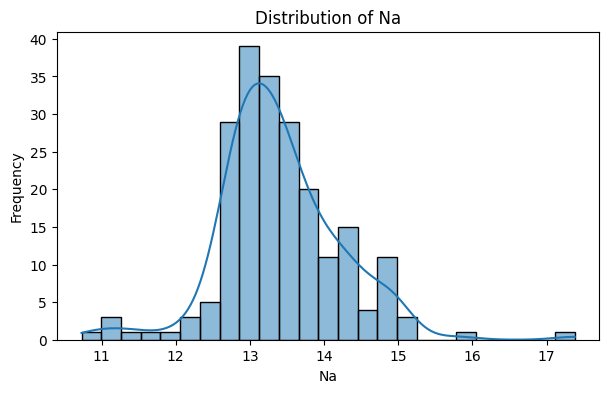

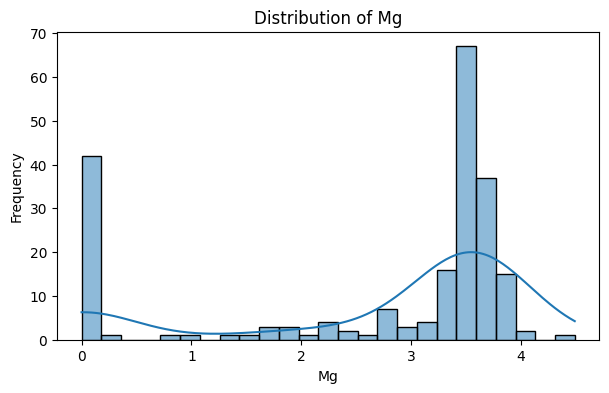

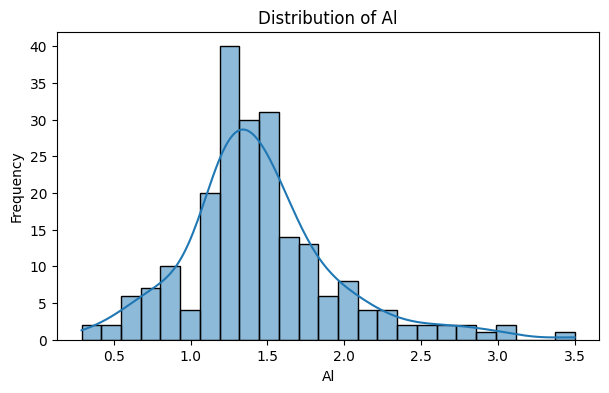

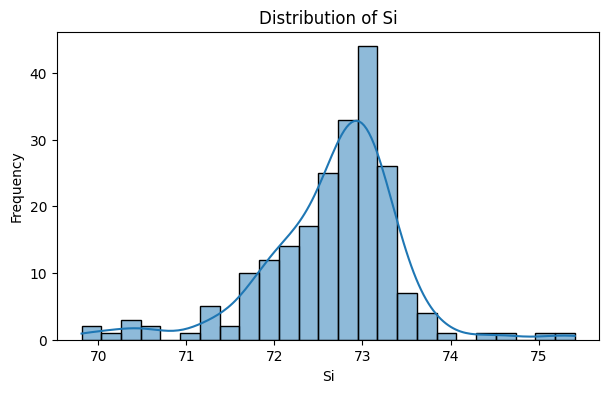

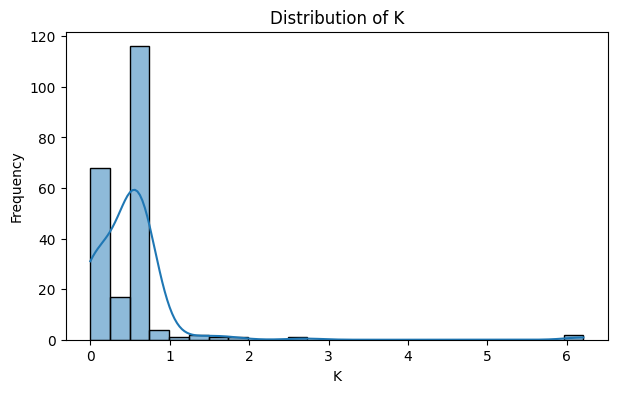

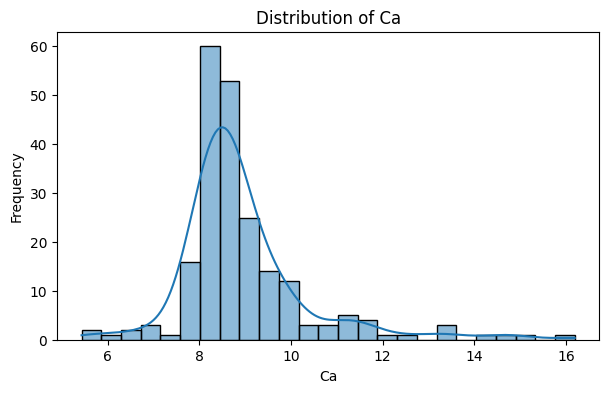

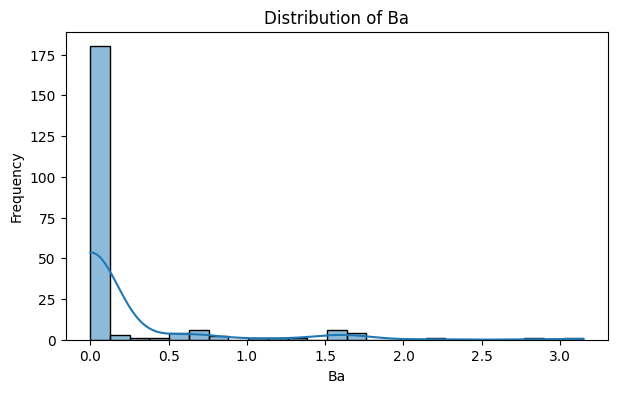

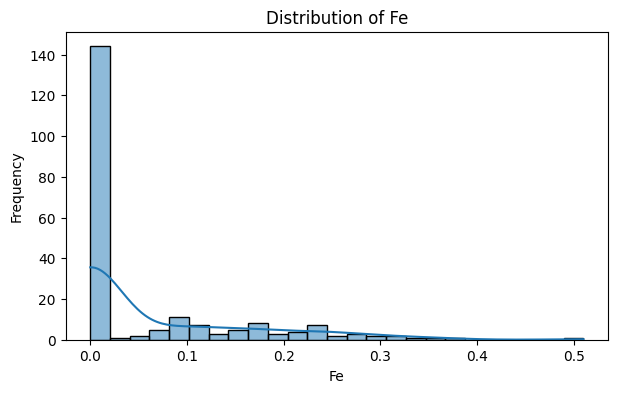

In [7]:
feature_columns = df.drop(columns=["Type"]).columns.tolist()

for col in feature_columns:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True, bins=25)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

## 7.3 Boxplots for Outlier Detection

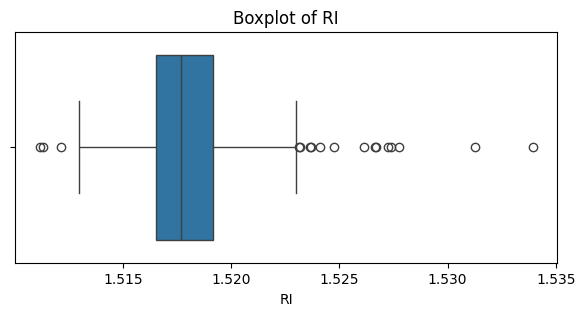

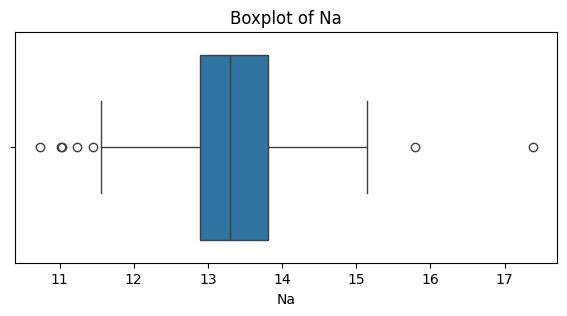

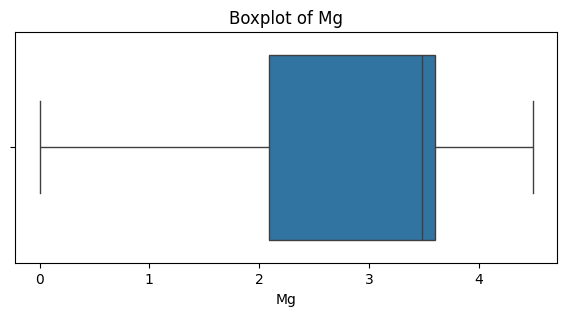

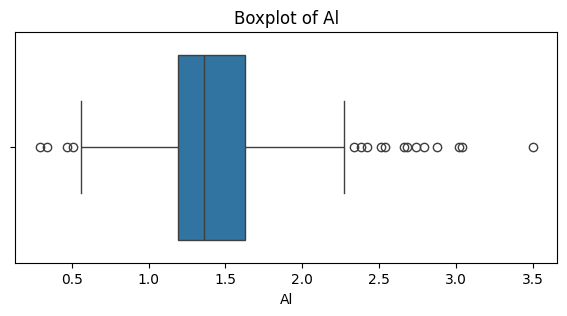

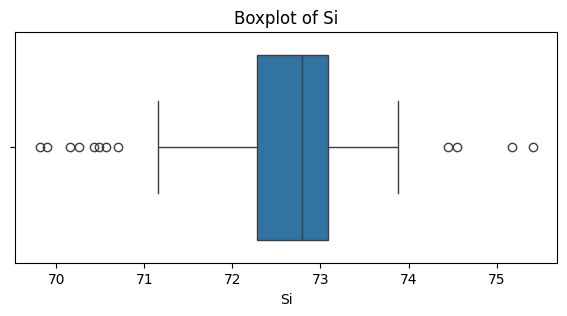

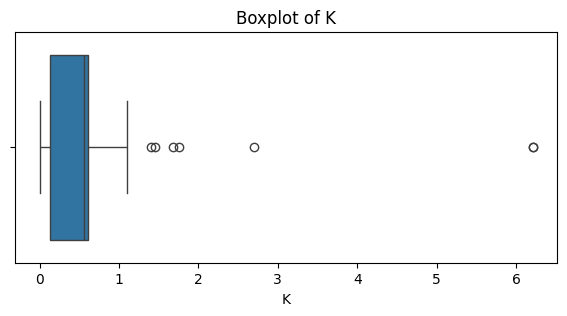

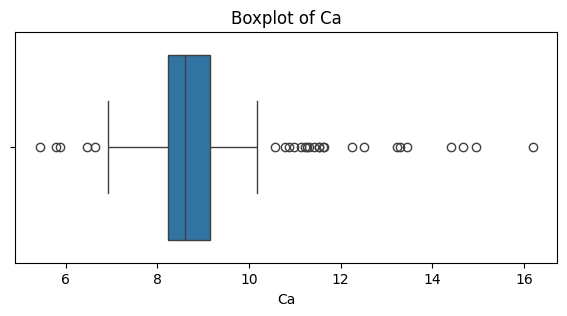

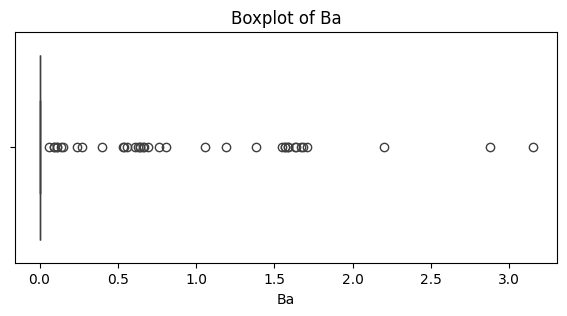

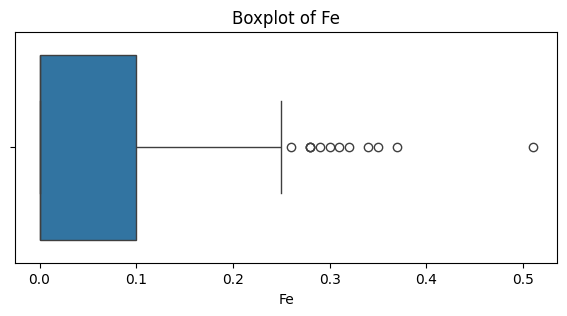

In [8]:
for col in feature_columns:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## 7.4 Pair Plot

Pair plot helps visualize relationships between features and classes.

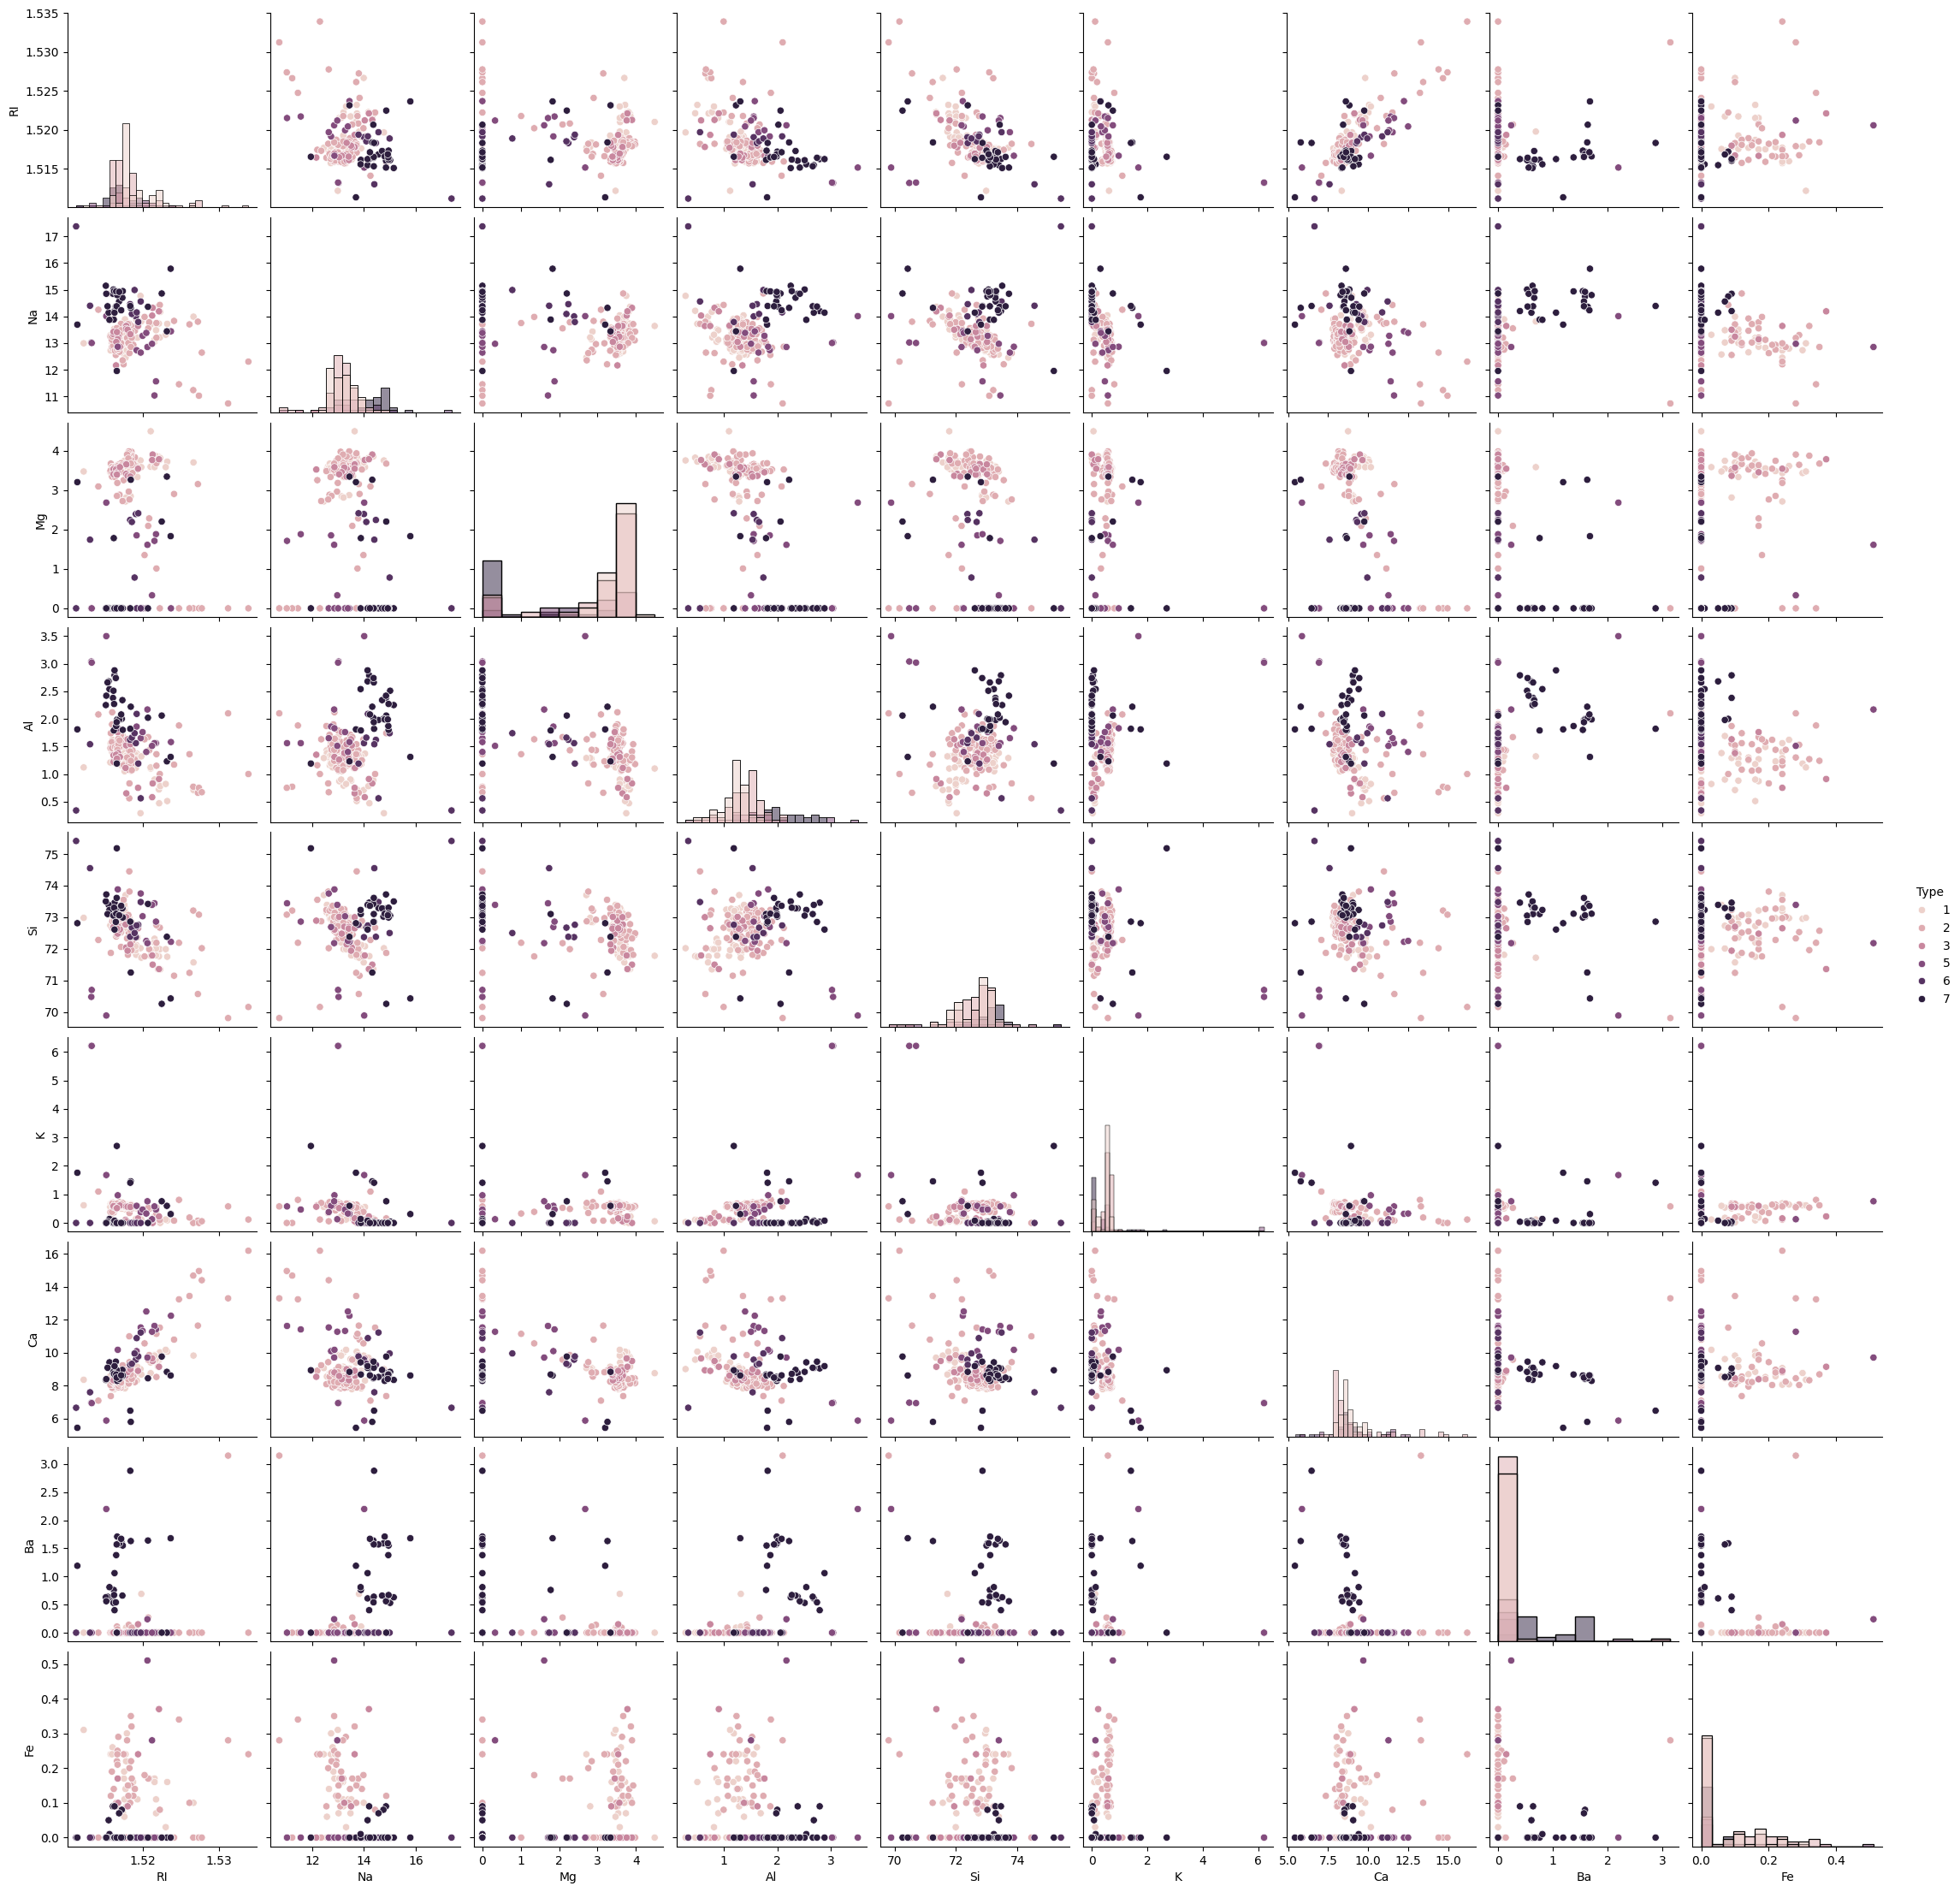

In [9]:
# Pairplot can take some time but is useful for visual analysis
sns.pairplot(df, hue="Type", diag_kind="hist")
plt.show()

## 7.5 Correlation Heatmap

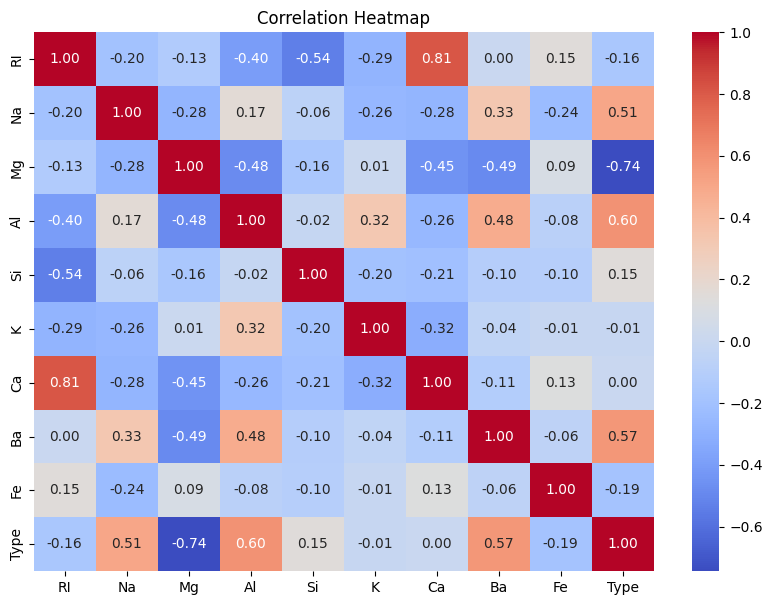

In [10]:
plt.figure(figsize=(10,7))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## 8. Outlier Treatment

Random Forest is less sensitive to outliers compared to linear models because it uses tree-based splitting.  
However, for a clean preprocessing workflow, we can cap outliers using the IQR method.

In [11]:
df_capped = df.copy()

for col in feature_columns:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df_capped[col] = np.where(df_capped[col] < lower_limit, lower_limit, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > upper_limit, upper_limit, df_capped[col])

print("Outlier capping completed.")
display(df_capped.head())

Outlier capping completed.


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


## 9. Separate Features and Target

In [12]:
X = df_capped.drop(columns=["Type"])
y = df_capped["Type"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Distribution:")
print(y.value_counts().sort_index())

Feature Shape: (213, 9)
Target Shape: (213,)

Target Distribution:
Type
1    69
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


## 10. Train-Test Split

The dataset is split into:

- 80% training data
- 20% testing data

`stratify=y` is used to preserve class distribution in train and test data.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting Target Distribution:")
print(y_test.value_counts().sort_index())

X_train shape: (170, 9)
X_test shape: (43, 9)
y_train shape: (170,)
y_test shape: (43,)

Training Target Distribution:
Type
1    55
2    61
3    14
5    10
6     7
7    23
Name: count, dtype: int64

Testing Target Distribution:
Type
1    14
2    15
3     3
5     3
6     2
7     6
Name: count, dtype: int64


## 11. Feature Scaling

Random Forest does not strictly require feature scaling.  
But scaling is included as a preprocessing step because the assignment asks for feature scaling techniques.

In [14]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


## 12. Random Forest Model Implementation

`class_weight="balanced"` is used to help handle imbalance in the target classes.

In [15]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_scaled, y_train)

rf_pred = rf_model.predict(X_test_scaled)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


## 13. Random Forest Model Evaluation

In [16]:
def evaluate_classifier(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print(f"Evaluation Metrics for {model_name}")
    print("-" * 45)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

results = []

results.append(evaluate_classifier(y_test, rf_pred, "Random Forest"))

Evaluation Metrics for Random Forest
---------------------------------------------
Accuracy : 0.7907
Precision: 0.8031
Recall   : 0.7907
F1 Score : 0.7904

Classification Report:
              precision    recall  f1-score   support

           1       0.80      0.86      0.83        14
           2       0.73      0.73      0.73        15
           3       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       0.83      0.83      0.83         6

    accuracy                           0.79        43
   macro avg       0.84      0.79      0.80        43
weighted avg       0.80      0.79      0.79        43



## 14. Random Forest Confusion Matrix

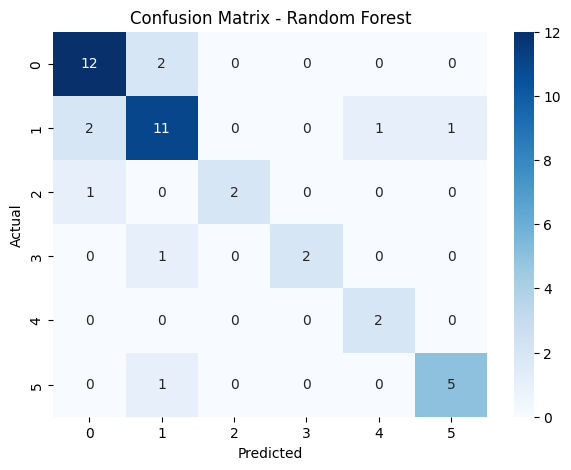

In [17]:
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 15. Feature Importance

,Feature,Importance
2,Mg,0.184708
1,Na,0.151036
3,Al,0.145309
6,Ca,0.142850
0,RI,0.128958
5,K,0.121580
4,Si,0.099881
8,Fe,0.025679
7,Ba,0.000000


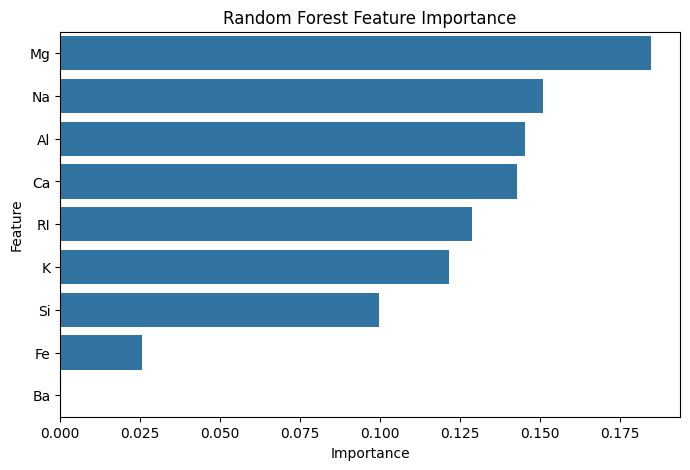

In [18]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(8,5))
sns.barplot(data=feature_importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.show()

## 16. Hyperparameter Tuning for Random Forest

We tune:

- `n_estimators`
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

In [19]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation F1 Score:
0.7723


## 17. Tuned Random Forest Evaluation

In [20]:
best_rf_model = grid_search.best_estimator_

best_rf_pred = best_rf_model.predict(X_test_scaled)

results.append(evaluate_classifier(y_test, best_rf_pred, "Tuned Random Forest"))

Evaluation Metrics for Tuned Random Forest
---------------------------------------------
Accuracy : 0.7907
Precision: 0.8031
Recall   : 0.7907
F1 Score : 0.7904

Classification Report:
              precision    recall  f1-score   support

           1       0.80      0.86      0.83        14
           2       0.73      0.73      0.73        15
           3       1.00      0.67      0.80         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       0.83      0.83      0.83         6

    accuracy                           0.79        43
   macro avg       0.84      0.79      0.80        43
weighted avg       0.80      0.79      0.79        43



# 18. Bagging Method

Bagging stands for Bootstrap Aggregating.

It trains multiple models on different random samples of the training data and combines their predictions.

Random Forest itself is a bagging-based method, but here we also apply a separate Bagging Classifier with Decision Tree.

In [21]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    n_estimators=100,
    random_state=42
)

bagging_model.fit(X_train_scaled, y_train)

bagging_pred = bagging_model.predict(X_test_scaled)

results.append(evaluate_classifier(y_test, bagging_pred, "Bagging Classifier"))

Evaluation Metrics for Bagging Classifier
---------------------------------------------
Accuracy : 0.7674
Precision: 0.7752
Recall   : 0.7674
F1 Score : 0.7663

Classification Report:
              precision    recall  f1-score   support

           1       0.80      0.86      0.83        14
           2       0.73      0.73      0.73        15
           3       1.00      0.67      0.80         3
           5       0.67      0.67      0.67         3
           6       0.67      1.00      0.80         2
           7       0.80      0.67      0.73         6

    accuracy                           0.77        43
   macro avg       0.78      0.77      0.76        43
weighted avg       0.78      0.77      0.77        43



# 19. Boosting Methods

Boosting trains models sequentially.  
Each new model focuses more on the mistakes made by the previous model.

We apply:

1. AdaBoost Classifier  
2. Gradient Boosting Classifier

In [22]:
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

adaboost_model.fit(X_train_scaled, y_train)

adaboost_pred = adaboost_model.predict(X_test_scaled)

results.append(evaluate_classifier(y_test, adaboost_pred, "AdaBoost Classifier"))

Evaluation Metrics for AdaBoost Classifier
---------------------------------------------
Accuracy : 0.4186
Precision: 0.3974
Recall   : 0.4186
F1 Score : 0.3868

Classification Report:
              precision    recall  f1-score   support

           1       0.43      0.71      0.54        14
           2       0.40      0.27      0.32        15
           3       0.00      0.00      0.00         3
           5       0.17      0.33      0.22         3
           6       0.00      0.00      0.00         2
           7       0.75      0.50      0.60         6

    accuracy                           0.42        43
   macro avg       0.29      0.30      0.28        43
weighted avg       0.40      0.42      0.39        43



In [23]:
gradient_boost_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gradient_boost_model.fit(X_train_scaled, y_train)

gradient_boost_pred = gradient_boost_model.predict(X_test_scaled)

results.append(evaluate_classifier(y_test, gradient_boost_pred, "Gradient Boosting Classifier"))

Evaluation Metrics for Gradient Boosting Classifier
---------------------------------------------
Accuracy : 0.814
Precision: 0.8295
Recall   : 0.814
F1 Score : 0.8147

Classification Report:
              precision    recall  f1-score   support

           1       0.92      0.79      0.85        14
           2       0.75      0.80      0.77        15
           3       0.75      1.00      0.86         3
           5       1.00      0.67      0.80         3
           6       0.67      1.00      0.80         2
           7       0.83      0.83      0.83         6

    accuracy                           0.81        43
   macro avg       0.82      0.85      0.82        43
weighted avg       0.83      0.81      0.81        43



## 20. Compare Random Forest, Bagging, and Boosting Models

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.790698,0.803101,0.790698,0.790377
1,Tuned Random Forest,0.790698,0.803101,0.790698,0.790377
2,Bagging Classifier,0.767442,0.775194,0.767442,0.766275
3,AdaBoost Classifier,0.418605,0.397371,0.418605,0.386843
4,Gradient Boosting Classifier,0.813953,0.829457,0.813953,0.814662


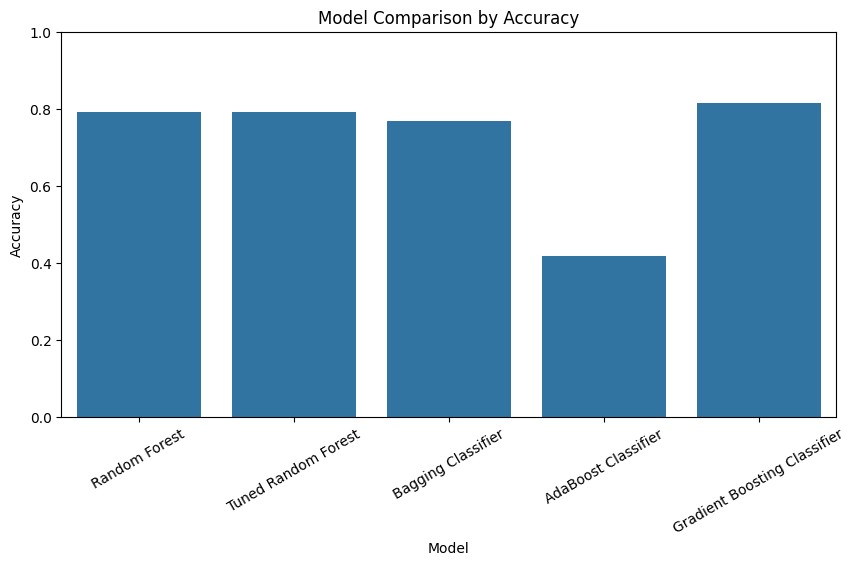

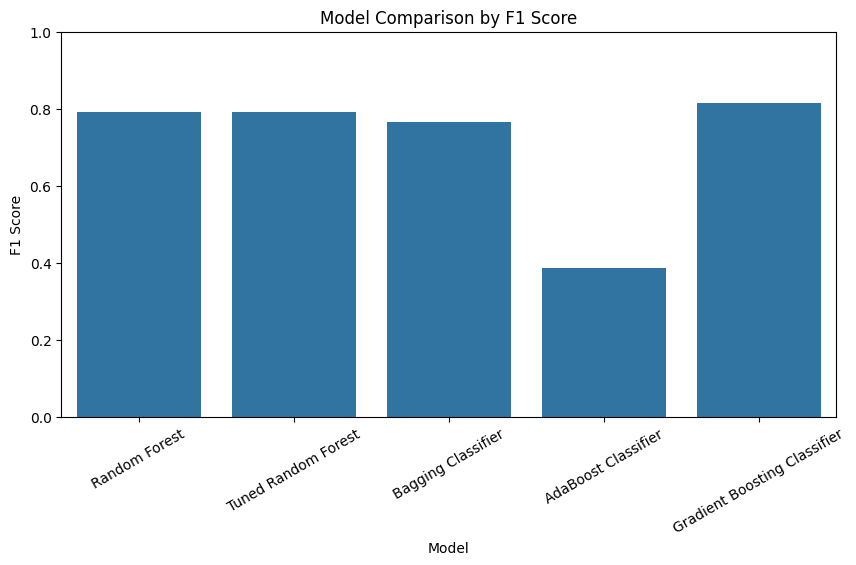

In [24]:
results_df = pd.DataFrame(results)

display(results_df)

plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Model", y="Accuracy")
plt.title("Model Comparison by Accuracy")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x="Model", y="F1 Score")
plt.title("Model Comparison by F1 Score")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.show()

## 21. Explanation: Bagging vs Boosting

### Bagging

Bagging means Bootstrap Aggregating.

In bagging:
- Multiple models are trained independently.
- Each model is trained on a different random sample of data.
- Final prediction is made by majority voting for classification.

Example:
- Random Forest
- Bagging Classifier

Advantages:
- Reduces variance
- Helps reduce overfitting
- Works well with unstable models like Decision Trees

### Boosting

Boosting trains models sequentially.

In boosting:
- First model is trained.
- Next model focuses more on previous mistakes.
- Models are combined to create a stronger classifier.

Examples:
- AdaBoost
- Gradient Boosting
- XGBoost

Advantages:
- Reduces bias
- Can improve accuracy
- Learns difficult patterns step by step

### Difference Between Bagging and Boosting

| Point | Bagging | Boosting |
|---|---|---|
| Training | Parallel / independent | Sequential |
| Main goal | Reduce variance | Reduce bias |
| Data sampling | Bootstrap samples | Weighted samples |
| Overfitting risk | Lower | Can overfit if not tuned |
| Example | Random Forest | AdaBoost, Gradient Boosting |

## 22. How to Handle Imbalanced Data

Imbalanced data means one class has many samples while another class has very few samples.

Common techniques to handle imbalance:

1. **Class Weighting**  
   Give higher weight to minority classes.  
   Example: `class_weight="balanced"` in Random Forest.

2. **Oversampling**  
   Increase minority class samples.  
   Example: Random oversampling or SMOTE.

3. **Undersampling**  
   Reduce majority class samples.

4. **Use Better Evaluation Metrics**  
   Accuracy alone may be misleading.  
   Use precision, recall, F1-score, and confusion matrix.

5. **Stratified Train-Test Split**  
   Maintains class distribution in training and testing sets.

In this notebook, imbalance is handled using:
- Stratified train-test split
- Class weighting
- Weighted precision, recall, and F1-score

## 23. Final Insights

1. The Glass dataset contains multiple chemical features useful for classification.
2. Some classes have fewer records, so class imbalance is present.
3. Random Forest performs well because it combines many decision trees.
4. Feature importance helps identify which chemical attributes are most useful.
5. Bagging reduces overfitting by averaging multiple decision trees.
6. Boosting improves weak models by learning from previous errors.
7. Weighted metrics are more suitable than accuracy when class imbalance exists.

## 24. Final Conclusion

In this assignment, the Glass dataset was analyzed and classified using Random Forest. EDA was performed using summary statistics, histograms, boxplots, pair plots, and correlation heatmap. Missing values, duplicates, outliers, and class imbalance were checked.

The dataset was split into training and testing sets. A Random Forest classifier was trained and evaluated using accuracy, precision, recall, and F1-score. Hyperparameter tuning was also applied to improve model performance.

Bagging and Boosting methods were implemented and compared with Random Forest. The comparison showed how ensemble methods improve classification performance by combining multiple weak or strong learners.

Overall, Random Forest is a strong model for this classification task because it handles non-linear patterns, reduces overfitting, and provides feature importance.